# Function 2 – Behavioral Anomaly Detection

Detects unusual teen phone-usage behaviour with two unsupervised models
(**Isolation Forest** and **One-Class SVM**), trained only on the original data.

Because the dataset has no anomaly labels, the models are evaluated on a
**controlled evaluation set**: untouched test records (label 0) mixed with
**synthetic anomalies** (label 1) created by pushing selected features beyond
data-driven percentile thresholds.

Pipeline: load → validate → select features → train/test split → scale →
baseline models → synthetic anomalies → tuning on a validation split →
final evaluation → robustness check → save artifacts.

In [1]:
import json
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    average_precision_score,
    precision_recall_curve
)

print("Libraries loaded successfully")
print("scikit-learn version:", sklearn.__version__)

Libraries loaded successfully
scikit-learn version: 1.6.1


## Step 1–2: Load and validate the dataset

In [2]:
# Load the original dataset
df = pd.read_csv("/content/teen_phone_addiction_dataset.csv")

print("Dataset loaded successfully")
print("Dataset shape:", df.shape)

# Preview first 5 records
display(df.head())

Dataset loaded successfully
Dataset shape: (3000, 25)


,ID,Name,Age,Gender,Location,School_Grade,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,...,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Phone_Usage_Purpose,Family_Communication,Weekend_Usage_Hours,Addiction_Level
0,1,Shannon Francis,13,Female,Hansonfort,9th,4.0,6.1,78,5,...,1.4,86,19,3.6,1.7,1.2,Browsing,4,8.7,10.0
1,2,Scott Rodriguez,17,Female,Theodorefort,7th,5.5,6.5,70,5,...,0.9,96,9,1.1,4.0,1.8,Browsing,2,5.3,10.0
2,3,Adrian Knox,13,Other,Lindseystad,11th,5.8,5.5,93,8,...,0.5,137,8,0.3,1.5,0.4,Education,6,5.7,9.2
3,4,Brittany Hamilton,18,Female,West Anthony,12th,3.1,3.9,78,8,...,1.4,128,7,3.1,1.6,0.8,Social Media,8,3.0,9.8
4,5,Steven Smith,14,Other,Port Lindsaystad,9th,2.5,6.7,56,4,...,1.0,96,20,2.6,0.9,1.1,Gaming,10,3.7,8.6


In [3]:
# ==========================================
# STEP 3: BASIC DATASET VALIDATION
# ==========================================

print("===== DATASET INFORMATION =====")
df.info()

print("\n===== MISSING VALUES =====")
print(df.isnull().sum())

print("\nTotal missing values:", df.isnull().sum().sum())

print("\n===== DUPLICATE ROWS =====")
print("Number of duplicate rows:", df.duplicated().sum())

print("\n===== NUMERICAL DATA SUMMARY =====")
display(df.describe())

===== DATASET INFORMATION =====
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 25 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ID                      3000 non-null   int64  
 1   Name                    3000 non-null   object 
 2   Age                     3000 non-null   int64  
 3   Gender                  3000 non-null   object 
 4   Location                3000 non-null   object 
 5   School_Grade            3000 non-null   object 
 6   Daily_Usage_Hours       3000 non-null   float64
 7   Sleep_Hours             3000 non-null   float64
 8   Academic_Performance    3000 non-null   int64  
 9   Social_Interactions     3000 non-null   int64  
 10  Exercise_Hours          3000 non-null   float64
 11  Anxiety_Level           3000 non-null   int64  
 12  Depression_Level        3000 non-null   int64  
 13  Self_Esteem             3000 non-null   int64  
 14  Parental

,ID,Age,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Anxiety_Level,Depression_Level,Self_Esteem,Parental_Control,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,Addiction_Level
count,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000,3000.000000
mean,1500.500000,15.969667,5.020667,6.489767,74.947333,5.097667,1.040667,5.590000,5.460333,5.546333,0.507333,1.006733,83.093000,12.609333,2.499233,1.525267,1.016333,5.459667,6.015100,8.881900
std,866.169729,1.989489,1.956501,1.490713,14.684156,3.139333,0.734620,2.890678,2.871557,2.860754,0.500030,0.492878,37.747044,4.611486,0.988201,0.932701,0.648341,2.864572,2.014776,1.609598
min,1.000000,13.000000,0.000000,3.000000,50.000000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,0.000000,20.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000
25%,750.750000,14.000000,3.700000,5.500000,62.000000,2.000000,0.500000,3.000000,3.000000,3.000000,0.000000,0.700000,51.000000,9.000000,1.800000,0.800000,0.500000,3.000000,4.700000,8.000000
50%,1500.500000,16.000000,5.000000,6.500000,75.000000,5.000000,1.000000,6.000000,5.000000,6.000000,1.000000,1.000000,82.000000,13.000000,2.500000,1.500000,1.000000,5.000000,6.000000,10.000000
75%,2250.250000,18.000000,6.400000,7.500000,88.000000,8.000000,1.500000,8.000000,8.000000,8.000000,1.000000,1.400000,115.250000,17.000000,3.200000,2.200000,1.500000,8.000000,7.400000,10.000000
max,3000.000000,19.000000,11.500000,10.000000,100.000000,10.000000,4.000000,10.000000,10.000000,10.000000,1.000000,2.600000,150.000000,20.000000,5.000000,4.000000,3.000000,10.000000,14.000000,10.000000


## Step 3: Select behavioral features

Only behavioral / lifestyle features are used. Identity columns (ID, Name,
Location), demographics, mental-health scores and the `Addiction_Level`
target are excluded so the detector does not rely on outcome labels.

The structure check below measures how related the features are. Very low
correlations mean the models can mainly detect extreme single values rather
than unusual combinations – this is a property of the dataset, reported in
the Limitations section.

In [4]:
# ==========================================
# STEP 4: SELECT BEHAVIORAL FEATURES
# ==========================================

behavioral_features = [
    "Daily_Usage_Hours",
    "Sleep_Hours",
    "Academic_Performance",
    "Social_Interactions",
    "Exercise_Hours",
    "Screen_Time_Before_Bed",
    "Phone_Checks_Per_Day",
    "Apps_Used_Daily",
    "Time_on_Social_Media",
    "Time_on_Gaming",
    "Time_on_Education",
    "Family_Communication",
    "Weekend_Usage_Hours"
]

# Create Function 2 dataset
X = df[behavioral_features].copy()

print("Behavioral dataset created successfully")
print("Shape:", X.shape)

print("\nSelected behavioral features:")
for feature in behavioral_features:
    print("-", feature)

print("\n===== FEATURE RANGES =====")
feature_ranges = pd.DataFrame({
    "Min": X.min(),
    "Max": X.max(),
    "Mean": X.mean(),
    "Median": X.median()
})

display(feature_ranges)

Behavioral dataset created successfully
Shape: (3000, 13)

Selected behavioral features:
- Daily_Usage_Hours
- Sleep_Hours
- Academic_Performance
- Social_Interactions
- Exercise_Hours
- Screen_Time_Before_Bed
- Phone_Checks_Per_Day
- Apps_Used_Daily
- Time_on_Social_Media
- Time_on_Gaming
- Time_on_Education
- Family_Communication
- Weekend_Usage_Hours

===== FEATURE RANGES =====


,Min,Max,Mean,Median
Daily_Usage_Hours,0.0,11.5,5.020667,5.0
Sleep_Hours,3.0,10.0,6.489767,6.5
Academic_Performance,50.0,100.0,74.947333,75.0
Social_Interactions,0.0,10.0,5.097667,5.0
Exercise_Hours,0.0,4.0,1.040667,1.0
Screen_Time_Before_Bed,0.0,2.6,1.006733,1.0
Phone_Checks_Per_Day,20.0,150.0,83.093000,82.0
Apps_Used_Daily,5.0,20.0,12.609333,13.0
Time_on_Social_Media,0.0,5.0,2.499233,2.5
Time_on_Gaming,0.0,4.0,1.525267,1.5


In [5]:
# ==========================================
# FEATURE STRUCTURE CHECK
# ==========================================

corr = X.corr().abs().values
np.fill_diagonal(corr, 0)

time_breakdown = (
    X["Time_on_Social_Media"]
    + X["Time_on_Gaming"]
    + X["Time_on_Education"]
)

inconsistent_share = (time_breakdown > X["Daily_Usage_Hours"]).mean()

print("Largest absolute correlation between two features:", round(corr.max(), 3))
print(
    "Records where social + gaming + education time > daily usage:",
    f"{inconsistent_share:.1%}"
)

Largest absolute correlation between two features: 0.042
Records where social + gaming + education time > daily usage: 49.2%


## Step 4–5: Train/test split and scaling

The scaler is fitted on the training set only and reused everywhere else,
so no information from the test data leaks into training.

In [6]:
# ==========================================
# STEP 5: TRAIN / TEST SPLIT
# ==========================================

X_train, X_test = train_test_split(
    X,
    test_size=0.20,
    random_state=42
)

print("Train/Test split completed successfully")

print("\nFull dataset shape :", X.shape)
print("Training set shape:", X_train.shape)
print("Testing set shape :", X_test.shape)

print("\nTraining percentage:",
      round(len(X_train) / len(X) * 100, 2), "%")

print("Testing percentage:",
      round(len(X_test) / len(X) * 100, 2), "%")

Train/Test split completed successfully

Full dataset shape : (3000, 13)
Training set shape: (2400, 13)
Testing set shape : (600, 13)

Training percentage: 80.0 %
Testing percentage: 20.0 %


In [7]:
# ==========================================
# STEP 6: FEATURE SCALING
# ==========================================

# Create the scaler
scaler = StandardScaler()

# Fit ONLY on training data
X_train_scaled = scaler.fit_transform(X_train)

# Use the same fitted scaler to transform test data
X_test_scaled = scaler.transform(X_test)

print("Feature scaling completed successfully")

print("\nTraining scaled shape:", X_train_scaled.shape)
print("Testing scaled shape :", X_test_scaled.shape)

# Check the scaled training data
print("\nMean of scaled training features:")
print(np.round(X_train_scaled.mean(axis=0), 2))

print("\nStandard deviation of scaled training features:")
print(np.round(X_train_scaled.std(axis=0), 2))

Feature scaling completed successfully

Training scaled shape: (2400, 13)
Testing scaled shape : (600, 13)

Mean of scaled training features:
[ 0.  0. -0.  0. -0. -0. -0.  0.  0. -0. -0.  0.  0.]

Standard deviation of scaled training features:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## Step 6: Baseline models (untuned)

Default settings (`contamination=0.10`, `nu=0.10`) as a first sanity check.
These are **not** the final models – tuning happens in Step 12.

In [8]:
# ==========================================
# STEP 7: TRAIN ISOLATION FOREST
# ==========================================

iso_forest = IsolationForest(
    n_estimators=100,
    contamination=0.10,
    random_state=42
)

# Train the model using training data
iso_forest.fit(X_train_scaled)

# Predictions on test data
#  1 = normal
# -1 = anomaly
iso_predictions = iso_forest.predict(X_test_scaled)

# Anomaly scores
iso_scores = iso_forest.decision_function(X_test_scaled)

print("Isolation Forest trained successfully")

# Count predictions
normal_count = np.sum(iso_predictions == 1)
anomaly_count = np.sum(iso_predictions == -1)

print("\n===== ISOLATION FOREST RESULTS =====")
print("Normal records :", normal_count)
print("Anomaly records:", anomaly_count)

print("\nNormal percentage:",
      round(normal_count / len(iso_predictions) * 100, 2), "%")

print("Anomaly percentage:",
      round(anomaly_count / len(iso_predictions) * 100, 2), "%")

print("\nFirst 10 predictions:")
print(iso_predictions[:10])

print("\nFirst 10 anomaly scores:")
print(np.round(iso_scores[:10], 4))

Isolation Forest trained successfully

===== ISOLATION FOREST RESULTS =====
Normal records : 526
Anomaly records: 74

Normal percentage: 87.67 %
Anomaly percentage: 12.33 %

First 10 predictions:
[ 1  1  1  1  1  1 -1  1 -1  1]

First 10 anomaly scores:
[ 0.0692  0.082   0.0168  0.04    0.0669  0.0357 -0.0138  0.0382 -0.0131
  0.0745]


In [9]:
# ==========================================
# STEP 8: TRAIN ONE-CLASS SVM
# ==========================================

oc_svm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.10
)

# Train model
oc_svm.fit(X_train_scaled)

# Predictions on test data
#  1 = normal
# -1 = anomaly
svm_predictions = oc_svm.predict(X_test_scaled)

# Anomaly scores
svm_scores = oc_svm.decision_function(X_test_scaled)

print("One-Class SVM trained successfully")

# Count predictions
svm_normal_count = np.sum(svm_predictions == 1)
svm_anomaly_count = np.sum(svm_predictions == -1)

print("\n===== ONE-CLASS SVM RESULTS =====")
print("Normal records :", svm_normal_count)
print("Anomaly records:", svm_anomaly_count)

print("\nNormal percentage:",
      round(svm_normal_count / len(svm_predictions) * 100, 2), "%")

print("Anomaly percentage:",
      round(svm_anomaly_count / len(svm_predictions) * 100, 2), "%")

print("\nFirst 10 predictions:")
print(svm_predictions[:10])

print("\nFirst 10 anomaly scores:")
print(np.round(svm_scores[:10], 4))

One-Class SVM trained successfully

===== ONE-CLASS SVM RESULTS =====
Normal records : 529
Anomaly records: 71

Normal percentage: 88.17 %
Anomaly percentage: 11.83 %

First 10 predictions:
[ 1  1  1  1  1  1 -1  1 -1  1]

First 10 anomaly scores:
[12.9992 12.9418  2.2948  5.675  10.2269  2.9235 -2.8821  4.8723 -2.2645
 15.0737]


## Step 7: Data-driven anomaly thresholds

Percentile thresholds from the training data define what "abnormally high"
(95th percentile) or "abnormally low" (5th percentile) means for each feature.

In [10]:
# ==========================================
# STEP 10: CALCULATE DATA-DRIVEN THRESHOLDS
# ==========================================

thresholds = {
    "Daily_Usage_Hours_high":
        X_train["Daily_Usage_Hours"].quantile(0.95),

    "Sleep_Hours_low":
        X_train["Sleep_Hours"].quantile(0.05),

    "Phone_Checks_Per_Day_high":
        X_train["Phone_Checks_Per_Day"].quantile(0.95),

    "Screen_Time_Before_Bed_high":
        X_train["Screen_Time_Before_Bed"].quantile(0.95),

    "Time_on_Social_Media_high":
        X_train["Time_on_Social_Media"].quantile(0.95),

    "Time_on_Gaming_high":
        X_train["Time_on_Gaming"].quantile(0.95),

    "Weekend_Usage_Hours_high":
        X_train["Weekend_Usage_Hours"].quantile(0.95)
}

print("===== DATA-DRIVEN ANOMALY THRESHOLDS =====")

for feature, value in thresholds.items():
    print(f"{feature}: {value:.2f}")

===== DATA-DRIVEN ANOMALY THRESHOLDS =====
Daily_Usage_Hours_high: 8.20
Sleep_Hours_low: 4.00
Phone_Checks_Per_Day_high: 143.00
Screen_Time_Before_Bed_high: 1.80
Time_on_Social_Media_high: 4.20
Time_on_Gaming_high: 3.10
Weekend_Usage_Hours_high: 9.30


## Step 8: Generate synthetic anomalies (with variation)

Three behavioral anomaly patterns are injected into copies of test records.
For each record, every pattern feature is drawn **at random** from the
anomalous part of its range, then rounded to the data's precision:

- high features: `Uniform(threshold + step, train_max)`
- low features: `Uniform(train_min, threshold − step)`

Adding/subtracting one `step` guarantees the rounded value is strictly beyond
the threshold, and the upper/lower bound keeps it inside the observed range.
The generator is a function so it can be reused in the robustness check.

In [11]:
PATTERNS = {
    "high_usage_low_sleep": [
        ("Daily_Usage_Hours", "high", 1),
        ("Sleep_Hours", "low", 1),
        ("Phone_Checks_Per_Day", "high", 0),
    ],
    "night_social_low_sleep": [
        ("Screen_Time_Before_Bed", "high", 1),
        ("Time_on_Social_Media", "high", 1),
        ("Sleep_Hours", "low", 1),
    ],
    "weekend_gaming_high_usage": [
        ("Weekend_Usage_Hours", "high", 1),
        ("Time_on_Gaming", "high", 1),
        ("Daily_Usage_Hours", "high", 1),
    ],
}


def sample_anomalous_values(feature, direction, n, decimals, rng, threshold_table=None):
    threshold_table = thresholds if threshold_table is None else threshold_table
    step = 10 ** -decimals

    if direction == "high":
        low = threshold_table[f"{feature}_high"] + step
        high = X_train[feature].max()
    else:
        low = X_train[feature].min()
        high = threshold_table[f"{feature}_low"] - step

    # Guard: no room left between the threshold and the observed min/max
    if low > high + 1e-9:
        raise ValueError(f"No anomalous range left for {feature} ({direction})")

    values = np.round(rng.uniform(low, high, n), decimals)
    return values.astype(X_train[feature].dtype)


def make_synthetic_anomalies(source, n_per_pattern, seed, threshold_table=None, patterns=None):
    patterns = PATTERNS if patterns is None else patterns
    rng = np.random.default_rng(seed)

    anomalies = source.sample(
        n=n_per_pattern * len(patterns),
        random_state=seed
    ).copy()

    anomalies["ground_truth_anomaly"] = 1
    anomalies["anomaly_type"] = ""

    for i, (name, rules) in enumerate(patterns.items()):
        idx = anomalies.index[i * n_per_pattern:(i + 1) * n_per_pattern]

        for feature, direction, decimals in rules:
            anomalies.loc[idx, feature] = sample_anomalous_values(
                feature, direction, len(idx), decimals, rng, threshold_table
            )

        anomalies.loc[idx, "anomaly_type"] = name

    return anomalies


def matches_pattern(data, rules, threshold_table=None):
    # True for rows where every feature of the pattern is beyond its threshold
    threshold_table = thresholds if threshold_table is None else threshold_table
    match = pd.Series(True, index=data.index)

    for feature, direction, _ in rules:
        if direction == "high":
            match &= data[feature] > threshold_table[f"{feature}_high"]
        else:
            match &= data[feature] < threshold_table[f"{feature}_low"]

    return match


synthetic_anomalies = make_synthetic_anomalies(
    X_test,
    n_per_pattern=20,
    seed=42
)

synthetic_indices = synthetic_anomalies.index

print("Synthetic anomalies generated successfully")
print("\nTotal synthetic anomalies:", len(synthetic_anomalies))

print("\n===== ANOMALY TYPES =====")
print(synthetic_anomalies["anomaly_type"].value_counts())

display(synthetic_anomalies.head())

Synthetic anomalies generated successfully

Total synthetic anomalies: 60

===== ANOMALY TYPES =====
anomaly_type
high_usage_low_sleep         20
night_social_low_sleep       20
weekend_gaming_high_usage    20
Name: count, dtype: int64


,Daily_Usage_Hours,Sleep_Hours,Academic_Performance,Social_Interactions,Exercise_Hours,Screen_Time_Before_Bed,Phone_Checks_Per_Day,Apps_Used_Daily,Time_on_Social_Media,Time_on_Gaming,Time_on_Education,Family_Communication,Weekend_Usage_Hours,ground_truth_anomaly,anomaly_type
2986,10.8,3.7,81,9,1.4,0.4,147,12,2.0,1.7,1.5,3,5.9,1,high_usage_low_sleep
410,9.7,3.3,87,9,1.0,0.0,149,5,1.6,1.3,1.0,6,6.0,1,high_usage_low_sleep
1920,11.0,3.9,93,9,0.7,1.1,148,15,3.6,1.2,1.7,3,4.7,1,high_usage_low_sleep
2724,10.5,3.8,71,1,0.0,1.8,146,7,2.3,2.9,2.1,4,10.5,1,high_usage_low_sleep
2677,8.6,3.7,95,7,0.8,1.9,149,9,2.8,1.0,1.9,1,6.5,1,high_usage_low_sleep


## Step 9: Validate the synthetic anomalies

Checks: no missing values, all values inside the observed training range,
every record satisfies its pattern rule, the injected values actually vary,
and – importantly – **no original record already matches any pattern**, so
the injected combinations are genuinely absent from the real data.

In [12]:
print("===== 1. BASIC VALIDATION =====")

missing_values = synthetic_anomalies[behavioral_features].isnull().sum().sum()
duplicate_rows = synthetic_anomalies[behavioral_features].duplicated().sum()

print("Total synthetic records:", len(synthetic_anomalies))
print("Missing values:", missing_values)
print("Duplicate rows:", duplicate_rows)


print("\n===== 2. RANGE VALIDATION =====")

range_results = {}

for feature in behavioral_features:
    valid = synthetic_anomalies[feature].between(
        X_train[feature].min(),
        X_train[feature].max()
    ).all()

    range_results[feature] = valid
    print(f"{feature}: {'PASS' if valid else 'FAIL'}")


print("\n===== 3. ANOMALY RULE VALIDATION =====")

pattern_results = {}

for name, rules in PATTERNS.items():
    rows = synthetic_anomalies[synthetic_anomalies["anomaly_type"] == name]
    valid = matches_pattern(rows, rules).all()

    pattern_results[name] = valid
    print(f"{name}: {'PASS' if valid else 'FAIL'}")


print("\n===== 4. VARIATION CHECK =====")
print("Distinct injected values per pattern feature (20 records each):")

for name, rules in PATTERNS.items():
    rows = synthetic_anomalies[synthetic_anomalies["anomaly_type"] == name]
    counts = {feature: rows[feature].nunique() for feature, _, _ in rules}
    print(f"{name}: {counts}")


print("\n===== 5. LABEL VALIDATION =====")

label_valid = (synthetic_anomalies["ground_truth_anomaly"] == 1).all()
print("All synthetic records labelled anomaly:", "PASS" if label_valid else "FAIL")


print("\n===== 6. NATURAL OCCURRENCE CHECK =====")
print("Original records (full dataset) that already match a pattern:")

natural_matches = {}

for name, rules in PATTERNS.items():
    natural_matches[name] = int(matches_pattern(df, rules).sum())
    print(f"{name}: {natural_matches[name]} of {len(df)}")

# 0 matches means the injected combinations do not occur in the real data,
# which supports labelling them as anomalies and the original records as 0.


overall_valid = (
    missing_values == 0
    and all(range_results.values())
    and all(pattern_results.values())
    and label_valid
)

print("\n===== FINAL RESULT =====")
print("SYNTHETIC DATA VALIDATION:", "PASS" if overall_valid else "FAIL")

===== 1. BASIC VALIDATION =====
Total synthetic records: 60
Missing values: 0
Duplicate rows: 0

===== 2. RANGE VALIDATION =====
Daily_Usage_Hours: PASS
Sleep_Hours: PASS
Academic_Performance: PASS
Social_Interactions: PASS
Exercise_Hours: PASS
Screen_Time_Before_Bed: PASS
Phone_Checks_Per_Day: PASS
Apps_Used_Daily: PASS
Time_on_Social_Media: PASS
Time_on_Gaming: PASS
Time_on_Education: PASS
Family_Communication: PASS
Weekend_Usage_Hours: PASS

===== 3. ANOMALY RULE VALIDATION =====
high_usage_low_sleep: PASS
night_social_low_sleep: PASS
weekend_gaming_high_usage: PASS

===== 4. VARIATION CHECK =====
Distinct injected values per pattern feature (20 records each):
high_usage_low_sleep: {'Daily_Usage_Hours': 16, 'Sleep_Hours': 9, 'Phone_Checks_Per_Day': 6}
night_social_low_sleep: {'Screen_Time_Before_Bed': 6, 'Time_on_Social_Media': 8, 'Sleep_Hours': 9}
weekend_gaming_high_usage: {'Weekend_Usage_Hours': 16, 'Time_on_Gaming': 9, 'Daily_Usage_Hours': 17}

===== 5. LABEL VALIDATION =====
Al

## Step 10: Build the controlled evaluation set

540 untouched test records (label 0) + 60 synthetic anomalies (label 1).

**Note:** label 0 means "not injected", not "verified normal" – some original
records may be genuine outliers, so precision is a conservative estimate.

In [13]:
# ==========================================
# STEP 13: BUILD CONTROLLED EVALUATION SET
# ==========================================

# Remove the 60 records that were selected for
# synthetic anomaly generation
reference_indices = X_test.index.difference(
    synthetic_indices
)

# 540 untouched original test records
reference_data = X_test.loc[
    reference_indices
].copy()

reference_data["ground_truth_anomaly"] = 0
reference_data["anomaly_type"] = "non_injected_original"


# Keep validated synthetic anomalies
synthetic_eval = synthetic_anomalies.copy()


# Combine both groups
evaluation_data = pd.concat(
    [reference_data, synthetic_eval],
    axis=0
)

# Shuffle evaluation dataset
evaluation_data = evaluation_data.sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


# Check final dataset
print("Controlled evaluation dataset created successfully")

print("\nTotal records:", len(evaluation_data))

print("\n===== CLASS DISTRIBUTION =====")
print(
    evaluation_data[
        "ground_truth_anomaly"
    ].value_counts().sort_index()
)

print("\n===== ANOMALY TYPES =====")
print(
    evaluation_data[
        "anomaly_type"
    ].value_counts()
)

print("\nMissing values:",
      evaluation_data[
          behavioral_features
      ].isnull().sum().sum())

Controlled evaluation dataset created successfully

Total records: 600

===== CLASS DISTRIBUTION =====
ground_truth_anomaly
0    540
1     60
Name: count, dtype: int64

===== ANOMALY TYPES =====
anomaly_type
non_injected_original        540
night_social_low_sleep        20
weekend_gaming_high_usage     20
high_usage_low_sleep          20
Name: count, dtype: int64

Missing values: 0


## Step 11: Baseline evaluation (untuned models)

Metrics used:
- **Precision / Recall / F1** for the anomaly class (main metrics).
- **PR-AUC** (average precision) from the continuous anomaly score – independent
  of the chosen threshold.
- **Accuracy** is shown for completeness only: with 90 % normal records, a model
  that flags nothing already scores 0.90.

In [14]:
def anomaly_score(model, X):
    # Higher = more anomalous (sklearn's decision_function is the opposite)
    return -model.decision_function(X)


def anomaly_metrics(model, X, y_true):
    y_pred = (model.predict(X) == -1).astype(int)
    scores = anomaly_score(model, X)

    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1 Score": f1_score(y_true, y_pred, zero_division=0),
        "PR-AUC": average_precision_score(y_true, scores),
    }, y_pred


X_eval_scaled = scaler.transform(evaluation_data[behavioral_features])
y_true = evaluation_data["ground_truth_anomaly"].values

iso_metrics, iso_y_pred = anomaly_metrics(iso_forest, X_eval_scaled, y_true)
svm_metrics, svm_y_pred = anomaly_metrics(oc_svm, X_eval_scaled, y_true)

results = pd.DataFrame(
    [iso_metrics, svm_metrics],
    index=["Isolation Forest", "One-Class SVM"]
)

print("===== BASELINE MODEL PERFORMANCE =====")
print("All-normal accuracy baseline:", round(1 - y_true.mean(), 4))
display(results.round(4))

print("\n===== ISOLATION FOREST CONFUSION MATRIX =====")
print(confusion_matrix(y_true, iso_y_pred))

print("\n===== ONE-CLASS SVM CONFUSION MATRIX =====")
print(confusion_matrix(y_true, svm_y_pred))

===== BASELINE MODEL PERFORMANCE =====
All-normal accuracy baseline: 0.9


,Accuracy,Precision,Recall,F1 Score,PR-AUC
Isolation Forest,0.8733,0.4298,0.8167,0.5632,0.6610
One-Class SVM,0.8917,0.4790,0.9500,0.6369,0.8074



===== ISOLATION FOREST CONFUSION MATRIX =====
[[475  65]
 [ 11  49]]

===== ONE-CLASS SVM CONFUSION MATRIX =====
[[478  62]
 [  3  57]]


## Step 12: Split into validation and final test sets

Half of the anomalies and half of the reference records are used for
hyperparameter tuning; the other half is kept untouched for the final result.

In [15]:
# ==========================================
# STEP 15: SPLIT SYNTHETIC ANOMALIES
# VALIDATION SET + FINAL TEST SET
# ==========================================

synthetic_validation, synthetic_final_test = train_test_split(
    synthetic_anomalies,
    test_size=0.50,
    random_state=42,
    stratify=synthetic_anomalies["anomaly_type"]
)

print("Synthetic anomaly split completed successfully")

print("\nValidation anomalies:",
      len(synthetic_validation))

print("Final test anomalies:",
      len(synthetic_final_test))

print("\n===== VALIDATION ANOMALY TYPES =====")
print(
    synthetic_validation[
        "anomaly_type"
    ].value_counts()
)

print("\n===== FINAL TEST ANOMALY TYPES =====")
print(
    synthetic_final_test[
        "anomaly_type"
    ].value_counts()
)

Synthetic anomaly split completed successfully

Validation anomalies: 30
Final test anomalies: 30

===== VALIDATION ANOMALY TYPES =====
anomaly_type
weekend_gaming_high_usage    10
high_usage_low_sleep         10
night_social_low_sleep       10
Name: count, dtype: int64

===== FINAL TEST ANOMALY TYPES =====
anomaly_type
night_social_low_sleep       10
high_usage_low_sleep         10
weekend_gaming_high_usage    10
Name: count, dtype: int64


In [16]:
# ==========================================
# STEP 16: CREATE VALIDATION AND FINAL
# REFERENCE SETS
# ==========================================

reference_validation, reference_final_test = train_test_split(
    reference_data,
    test_size=0.50,
    random_state=42
)

# ------------------------------------------
# Build validation dataset
# ------------------------------------------

validation_data = pd.concat(
    [
        reference_validation,
        synthetic_validation
    ],
    axis=0
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


# ------------------------------------------
# Build final test dataset
# ------------------------------------------

final_test_data = pd.concat(
    [
        reference_final_test,
        synthetic_final_test
    ],
    axis=0
).sample(
    frac=1,
    random_state=42
).reset_index(drop=True)


print("Validation and final test datasets created successfully")

print("\n===== VALIDATION SET =====")
print("Total:", len(validation_data))
print(
    validation_data[
        "ground_truth_anomaly"
    ].value_counts().sort_index()
)

print("\n===== FINAL TEST SET =====")
print("Total:", len(final_test_data))
print(
    final_test_data[
        "ground_truth_anomaly"
    ].value_counts().sort_index()
)

# Check overlap between original reference records
overlap = set(reference_validation.index).intersection(
    set(reference_final_test.index)
)

print("\nReference record overlap:", len(overlap))

Validation and final test datasets created successfully

===== VALIDATION SET =====
Total: 300
ground_truth_anomaly
0    270
1     30
Name: count, dtype: int64

===== FINAL TEST SET =====
Total: 300
ground_truth_anomaly
0    270
1     30
Name: count, dtype: int64

Reference record overlap: 0


## Step 13: Hyperparameter tuning (validation set only)

The grid is wider than the baseline run: in the first version the best values
(`contamination=0.03`, `nu=0.03`, `gamma=0.01`) were at the edge of the grid,
which means the optimum could lie outside it. A warning is printed if that
happens again. Models are always trained on the original training data only.

In [17]:
X_val_scaled = scaler.transform(validation_data[behavioral_features])
y_val = validation_data["ground_truth_anomaly"].values


def warn_if_on_edge(name, value, grid):
    if value in (grid[0], grid[-1]):
        print(f"WARNING: best {name}={value} is at the edge of the grid {grid}")


# ==========================================
# 1. ISOLATION FOREST TUNING
# ==========================================

contamination_values = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10]

iso_results = []

for contamination in contamination_values:
    model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42
    ).fit(X_train_scaled)

    metrics, _ = anomaly_metrics(model, X_val_scaled, y_val)
    iso_results.append({"contamination": contamination, **metrics})

iso_results_df = pd.DataFrame(iso_results).drop(columns="Accuracy")

print("===== ISOLATION FOREST TUNING =====")
display(iso_results_df.round(4))


# ==========================================
# 2. ONE-CLASS SVM TUNING
# ==========================================

nu_values = [0.005, 0.01, 0.02, 0.03, 0.05, 0.08, 0.10]
gamma_values = [0.001, 0.005, 0.01, 0.05, 0.1, "scale"]

svm_results = []

for nu in nu_values:
    for gamma in gamma_values:
        model = OneClassSVM(
            kernel="rbf",
            nu=nu,
            gamma=gamma
        ).fit(X_train_scaled)

        metrics, _ = anomaly_metrics(model, X_val_scaled, y_val)
        svm_results.append({"nu": nu, "gamma": gamma, **metrics})

svm_results_df = pd.DataFrame(svm_results).drop(columns="Accuracy")

print("\n===== ONE-CLASS SVM TUNING (top 10 by F1) =====")
display(svm_results_df.sort_values("F1 Score", ascending=False).head(10).round(4))


# ==========================================
# 3. BEST CONFIGURATIONS
# ==========================================

best_iso = iso_results_df.loc[iso_results_df["F1 Score"].idxmax()]
best_svm = svm_results_df.loc[svm_results_df["F1 Score"].idxmax()]

best_contamination = float(best_iso["contamination"])
best_nu = float(best_svm["nu"])
best_gamma = best_svm["gamma"]

print("\n===== BEST ISOLATION FOREST =====")
print(best_iso)

print("\n===== BEST ONE-CLASS SVM =====")
print(best_svm)

print()
warn_if_on_edge("contamination", best_contamination, contamination_values)
warn_if_on_edge("nu", best_nu, nu_values)
if best_gamma != "scale":
    warn_if_on_edge("gamma", best_gamma, gamma_values[:-1])

===== ISOLATION FOREST TUNING =====


,contamination,Precision,Recall,F1 Score,PR-AUC
0,0.005,0.8000,0.4000,0.5333,0.7177
1,0.010,0.8182,0.6000,0.6923,0.7177
2,0.020,0.7308,0.6333,0.6786,0.7177
3,0.030,0.6875,0.7333,0.7097,0.7177
4,0.050,0.5111,0.7667,0.6133,0.7177
5,0.080,0.4800,0.8000,0.6000,0.7177
6,0.100,0.4407,0.8667,0.5843,0.7177



===== ONE-CLASS SVM TUNING (top 10 by F1) =====


,nu,gamma,Precision,Recall,F1 Score,PR-AUC
15,0.020,0.05,0.7742,0.8000,0.7869,0.8057
20,0.030,0.01,0.7353,0.8333,0.7812,0.8060
18,0.030,0.001,0.7353,0.8333,0.7812,0.8060
19,0.030,0.005,0.7353,0.8333,0.7812,0.8062
13,0.020,0.005,0.7667,0.7667,0.7667,0.8063
14,0.020,0.01,0.7667,0.7667,0.7667,0.8072
9,0.010,0.05,0.7667,0.7667,0.7667,0.7904
12,0.020,0.001,0.7667,0.7667,0.7667,0.8055
3,0.005,0.05,0.7667,0.7667,0.7667,0.7904
25,0.050,0.005,0.6190,0.8667,0.7222,0.8130



===== BEST ISOLATION FOREST =====
contamination    0.030000
Precision        0.687500
Recall           0.733333
F1 Score         0.709677
PR-AUC           0.717668
Name: 3, dtype: float64

===== BEST ONE-CLASS SVM =====
nu               0.02
gamma            0.05
Precision    0.774194
Recall            0.8
F1 Score     0.786885
PR-AUC        0.80574
Name: 15, dtype: object



## Step 14: Final evaluation on the untouched test set

The tuned settings are taken directly from Step 13 (not typed in by hand),
so the notebook stays consistent if the data or grid changes.

In [18]:
final_iso = IsolationForest(
    n_estimators=200,
    contamination=best_contamination,
    random_state=42
).fit(X_train_scaled)

final_svm = OneClassSVM(
    kernel="rbf",
    nu=best_nu,
    gamma=best_gamma
).fit(X_train_scaled)

X_final_scaled = scaler.transform(final_test_data[behavioral_features])
y_final = final_test_data["ground_truth_anomaly"].values

iso_final_metrics, iso_final_pred = anomaly_metrics(final_iso, X_final_scaled, y_final)
svm_final_metrics, svm_final_pred = anomaly_metrics(final_svm, X_final_scaled, y_final)

final_results = pd.DataFrame(
    [iso_final_metrics, svm_final_metrics],
    index=["Isolation Forest", "One-Class SVM"]
)

print("===== FINAL TEST PERFORMANCE =====")
print(f"Isolation Forest: contamination={best_contamination}")
print(f"One-Class SVM   : nu={best_nu}, gamma={best_gamma}")
print("All-normal accuracy baseline:", round(1 - y_final.mean(), 4))
display(final_results.round(4))

print("\n===== ISOLATION FOREST CONFUSION MATRIX =====")
print(confusion_matrix(y_final, iso_final_pred))

print("\n===== ONE-CLASS SVM CONFUSION MATRIX =====")
print(confusion_matrix(y_final, svm_final_pred))


# ------------------------------------------
# Recall per anomaly type
# ------------------------------------------

is_anomaly = final_test_data["ground_truth_anomaly"] == 1

per_type_recall = pd.DataFrame({
    "Records": final_test_data[is_anomaly].groupby("anomaly_type").size(),
    "Isolation Forest": pd.Series(iso_final_pred[is_anomaly], index=final_test_data.index[is_anomaly])
        .groupby(final_test_data["anomaly_type"]).mean(),
    "One-Class SVM": pd.Series(svm_final_pred[is_anomaly], index=final_test_data.index[is_anomaly])
        .groupby(final_test_data["anomaly_type"]).mean(),
})

print("\n===== RECALL PER ANOMALY TYPE =====")
display(per_type_recall.round(4))

===== FINAL TEST PERFORMANCE =====
Isolation Forest: contamination=0.03
One-Class SVM   : nu=0.02, gamma=0.05
All-normal accuracy baseline: 0.9


,Accuracy,Precision,Recall,F1 Score,PR-AUC
Isolation Forest,0.9167,0.6000,0.5000,0.5455,0.6472
One-Class SVM,0.9533,0.7857,0.7333,0.7586,0.8409



===== ISOLATION FOREST CONFUSION MATRIX =====
[[260  10]
 [ 15  15]]

===== ONE-CLASS SVM CONFUSION MATRIX =====
[[264   6]
 [  8  22]]

===== RECALL PER ANOMALY TYPE =====


,Records,Isolation Forest,One-Class SVM
anomaly_type,,,
high_usage_low_sleep,10,0.2,0.8
night_social_low_sleep,10,0.6,0.7
weekend_gaming_high_usage,10,0.7,0.7


## Step 15: Visualise anomaly scores

Left/middle: score distributions for normal vs synthetic anomaly records – the
dashed line is the model's decision threshold (records to the right are flagged).
Right: precision–recall curves across all possible thresholds.

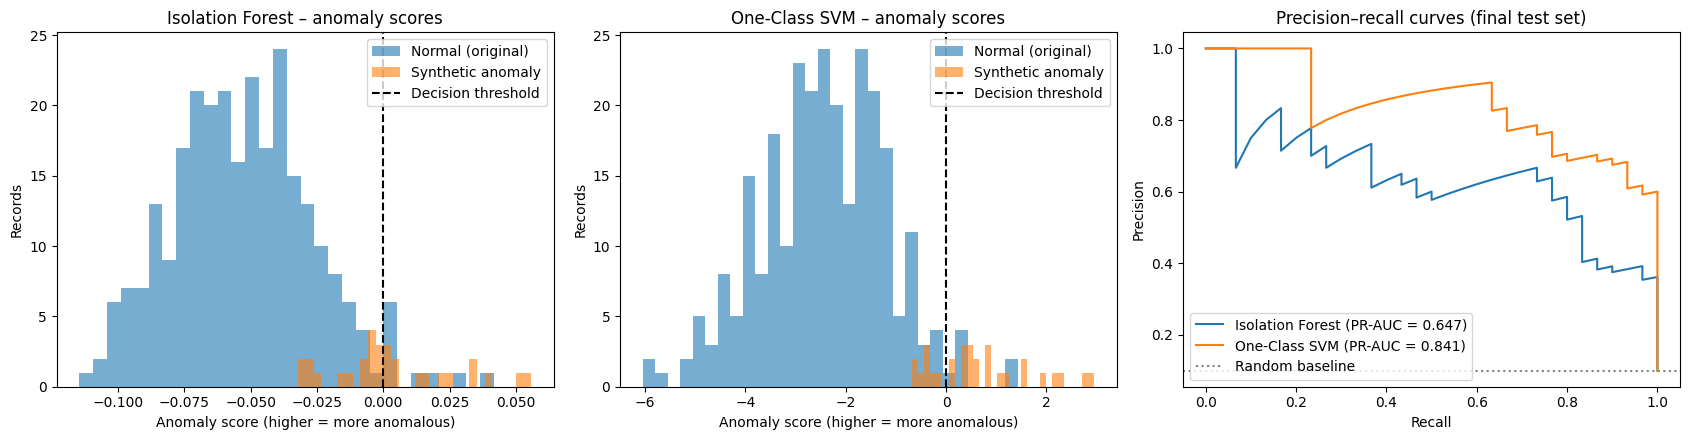

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

for ax, (name, model) in zip(
    axes[:2],
    [("Isolation Forest", final_iso), ("One-Class SVM", final_svm)]
):
    scores = anomaly_score(model, X_final_scaled)

    ax.hist(scores[y_final == 0], bins=30, alpha=0.6, label="Normal (original)")
    ax.hist(scores[y_final == 1], bins=30, alpha=0.6, label="Synthetic anomaly")
    ax.axvline(0, color="black", linestyle="--", label="Decision threshold")

    ax.set_title(f"{name} – anomaly scores")
    ax.set_xlabel("Anomaly score (higher = more anomalous)")
    ax.set_ylabel("Records")
    ax.legend()

for name, model in [("Isolation Forest", final_iso), ("One-Class SVM", final_svm)]:
    precision, recall, _ = precision_recall_curve(y_final, anomaly_score(model, X_final_scaled))
    ap = average_precision_score(y_final, anomaly_score(model, X_final_scaled))
    axes[2].plot(recall, precision, label=f"{name} (PR-AUC = {ap:.3f})")

axes[2].axhline(y_final.mean(), color="grey", linestyle=":", label="Random baseline")
axes[2].set_title("Precision–recall curves (final test set)")
axes[2].set_xlabel("Recall")
axes[2].set_ylabel("Precision")
axes[2].legend()

plt.tight_layout()
plt.show()

## Step 16: Robustness check across random seeds

The final test set has only 30 anomalies, so one or two records change the
scores noticeably. Here the tuned models are kept fixed and the evaluation is
repeated 20 times with different synthetic anomalies (different base records
and different injected values) and different reference records.

The models and hyperparameters are not changed, so this measures how much
the reported numbers depend on the particular sample, not a fresh tuning run.

In [20]:
N_SEEDS = 20

def build_seed_eval_set(seed, threshold_table=None, patterns=None, n_per_pattern=10):
    anomalies = make_synthetic_anomalies(
        X_test,
        n_per_pattern=n_per_pattern,
        seed=seed,
        threshold_table=threshold_table,
        patterns=patterns
    )

    reference = X_test.drop(anomalies.index).sample(n=270, random_state=seed).copy()
    reference["ground_truth_anomaly"] = 0

    eval_set = pd.concat([reference, anomalies], axis=0)

    X_seed = scaler.transform(eval_set[behavioral_features])
    y_seed = eval_set["ground_truth_anomaly"].values

    return X_seed, y_seed


robustness_rows = []

for seed in range(N_SEEDS):
    X_seed, y_seed = build_seed_eval_set(seed)

    for name, model in [("Isolation Forest", final_iso), ("One-Class SVM", final_svm)]:
        metrics, _ = anomaly_metrics(model, X_seed, y_seed)
        robustness_rows.append({"seed": seed, "Model": name, **metrics})

robustness_df = pd.DataFrame(robustness_rows)

robustness_summary = (
    robustness_df
    .drop(columns="seed")
    .groupby("Model")
    .agg(["mean", "std"])
)

print(f"===== PERFORMANCE OVER {N_SEEDS} SEEDS (mean ± std) =====")
display(robustness_summary.round(4))

svm_wins = (
    robustness_df.pivot(index="seed", columns="Model", values="F1 Score")
    .pipe(lambda d: (d["One-Class SVM"] > d["Isolation Forest"]).sum())
)
print(f"\nOne-Class SVM has higher F1 in {svm_wins} of {N_SEEDS} seeds")

===== PERFORMANCE OVER 20 SEEDS (mean ± std) =====


Accuracy         Precision          Recall         F1 Score  \
                     mean     std      mean     std    mean     std     mean   
Model                                                                          
Isolation Forest   0.9348  0.0089    0.6917  0.0513  0.6333  0.0649   0.6595   
One-Class SVM      0.9607  0.0108    0.8018  0.0469  0.8067  0.0856   0.8025   

                          PR-AUC          
                     std    mean     std  
Model                                     
Isolation Forest  0.0487  0.7284  0.0654  
One-Class SVM     0.0585  0.8585  0.0518


One-Class SVM has higher F1 in 20 of 20 seeds


## Step 17: Threshold sensitivity (90th / 95th / 99th percentile)

The 95th / 5th percentile cutoff used in Step 7 is a common convention, not
a fixed rule. This step checks how much the results depend on it by
regenerating the synthetic anomalies at three threshold levels:

| Level | High features | Low feature (sleep) | Anomalies are… |
|---|---|---|---|
| Mild | > 90th percentile | < 10th percentile | closer to normal – harder to detect |
| Standard | > 95th percentile | < 5th percentile | as used in the rest of the notebook |
| Extreme | > 99th percentile | < 1st percentile | very far from normal – easier to detect |

The tuned final models are **not retrained or retuned** – only the anomalies
change. Each level is evaluated over the same 20 seeds as Step 16.

At the extreme level some features have only one value left above the
threshold (e.g. Phone_Checks_Per_Day can only be 150, Sleep_Hours only 3.0),
so those anomalies have less variation.

===== THRESHOLDS PER LEVEL =====


,Mild (90th pct),Standard (95th pct),Extreme (99th pct)
Daily_Usage_Hours_high,7.5,8.200,9.3
Sleep_Hours_low,4.6,4.000,3.1
Phone_Checks_Per_Day_high,136.0,143.000,149.0
Screen_Time_Before_Bed_high,1.6,1.800,2.1
Time_on_Social_Media_high,3.8,4.200,4.9
Weekend_Usage_Hours_high,8.6,9.305,10.6
Time_on_Gaming_high,2.8,3.100,3.7



===== SENSITIVITY RESULTS OVER 20 SEEDS (mean, std) =====


Precision          Recall          \
                                          mean     std    mean     std   
Model            Level                                                   
Isolation Forest Mild (90th pct)        0.6432  0.0587  0.5133  0.0914   
One-Class SVM    Mild (90th pct)        0.7652  0.0575  0.6550  0.0999   
Isolation Forest Standard (95th pct)    0.6917  0.0513  0.6333  0.0649   
One-Class SVM    Standard (95th pct)    0.8018  0.0469  0.8067  0.0856   
Isolation Forest Extreme (99th pct)     0.7426  0.0440  0.8133  0.0556   
One-Class SVM    Extreme (99th pct)     0.8326  0.0381  0.9833  0.0171   

                                     F1 Score          PR-AUC          
                                         mean     std    mean     std  
Model            Level                                                 
Isolation Forest Mild (90th pct)       0.5678  0.0718  0.6272  0.0788  
One-Class SVM    Mild (90th pct)       0.7034  0.0758  0.7497  0.0737  
Isolation Forest Standard (95th pct)   0.6595  0.0487  0.7284  0.0654  
One-Class SVM    Standard (95th pct)   0.8025  0.0585  0.8585  0.0518  
Isolation Forest Extreme (99th pct)    0.7750  0.0379  0.8591  0.0410  
One-Class SVM    Extreme (99th pct)    0.9013  0.0256  0.9667  0.0170

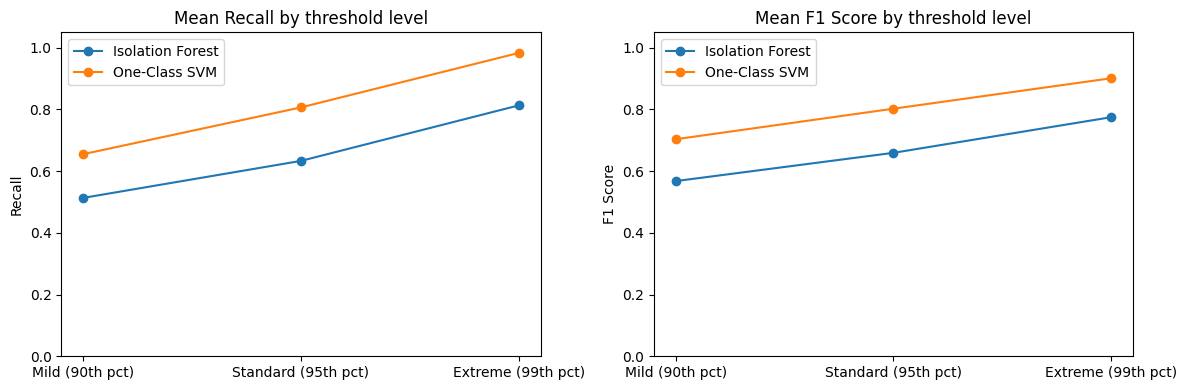

In [21]:
SENSITIVITY_LEVELS = {
    "Mild (90th pct)": 0.90,
    "Standard (95th pct)": 0.95,
    "Extreme (99th pct)": 0.99,
}


def make_thresholds(level, patterns=None):
    patterns = PATTERNS if patterns is None else patterns
    table = {}

    for rules in patterns.values():
        for feature, direction, _ in rules:
            if direction == "high":
                table[f"{feature}_high"] = X_train[feature].quantile(level)
            else:
                table[f"{feature}_low"] = X_train[feature].quantile(1 - level)

    return table


# ------------------------------------------
# 1. Threshold values at each level
# ------------------------------------------

threshold_levels = pd.DataFrame({
    label: make_thresholds(level)
    for label, level in SENSITIVITY_LEVELS.items()
})

print("===== THRESHOLDS PER LEVEL =====")
display(threshold_levels.round(3))


# ------------------------------------------
# 2. Evaluate the fixed final models
# ------------------------------------------

sensitivity_rows = []

for label, level in SENSITIVITY_LEVELS.items():
    level_thresholds = make_thresholds(level)

    for seed in range(N_SEEDS):
        X_seed, y_seed = build_seed_eval_set(seed, level_thresholds)

        for name, model in [("Isolation Forest", final_iso), ("One-Class SVM", final_svm)]:
            metrics, _ = anomaly_metrics(model, X_seed, y_seed)
            sensitivity_rows.append({"Level": label, "Model": name, **metrics})

sensitivity_df = pd.DataFrame(sensitivity_rows)

sensitivity_summary = (
    sensitivity_df
    .groupby(["Model", "Level"], sort=False)[["Precision", "Recall", "F1 Score", "PR-AUC"]]
    .agg(["mean", "std"])
)

print(f"\n===== SENSITIVITY RESULTS OVER {N_SEEDS} SEEDS (mean, std) =====")
display(sensitivity_summary.round(4))


# ------------------------------------------
# 3. Plot mean recall and F1 per level
# ------------------------------------------

means = sensitivity_df.groupby(["Model", "Level"], sort=False)[["Recall", "F1 Score"]].mean()
levels = list(SENSITIVITY_LEVELS)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, metric in zip(axes, ["Recall", "F1 Score"]):
    for name in ["Isolation Forest", "One-Class SVM"]:
        ax.plot(levels, means.loc[name, metric].reindex(levels), marker="o", label=name)

    ax.set_title(f"Mean {metric} by threshold level")
    ax.set_ylabel(metric)
    ax.set_ylim(0, 1.05)
    ax.legend()

plt.tight_layout()
plt.show()

## Step 18: Unseen anomaly patterns

The models were tuned using the three patterns from Step 8, so good scores on
those patterns could partly reflect tuning to them. Here two **new patterns
that were never used for tuning** are injected, and the fixed final models are
evaluated on them (20 seeds, 30 anomalies each).

| Pattern | Features pushed beyond threshold |
|---|---|
| academic_decline_social_overuse | low Academic_Performance, high Time_on_Social_Media, high Screen_Time_Before_Bed |
| compulsive_checking_gaming | high Phone_Checks_Per_Day, high Time_on_Gaming, high Weekend_Usage_Hours |

Similar scores to Step 16 indicate the models detect abnormal behaviour in
general, not only the patterns they were tuned on.

**Result:** both models still detect the unseen patterns (F1 about 0.67–0.74),
so they are not limited to the tuned patterns. However, the One-Class SVM's
clear lead on the tuned patterns largely disappears here – part of that lead
comes from being tuned on those specific patterns. (2 of 3,000 original records
already match `compulsive_checking_gaming`; at 0.07 % it is still rare enough
to count as anomalous.)

In [22]:
HELD_OUT_PATTERNS = {
    "academic_decline_social_overuse": [
        ("Academic_Performance", "low", 0),
        ("Time_on_Social_Media", "high", 1),
        ("Screen_Time_Before_Bed", "high", 1),
    ],
    "compulsive_checking_gaming": [
        ("Phone_Checks_Per_Day", "high", 0),
        ("Time_on_Gaming", "high", 1),
        ("Weekend_Usage_Hours", "high", 1),
    ],
}

held_out_thresholds = make_thresholds(0.95, HELD_OUT_PATTERNS)

print("===== NATURAL OCCURRENCE OF UNSEEN PATTERNS =====")
for name, rules in HELD_OUT_PATTERNS.items():
    matches = matches_pattern(df, rules, held_out_thresholds).sum()
    print(f"{name}: {matches} of {len(df)} original records")


# ------------------------------------------
# Evaluate fixed final models on each pattern
# ------------------------------------------

held_out_rows = []

for pattern_name, rules in HELD_OUT_PATTERNS.items():
    for seed in range(N_SEEDS):
        X_seed, y_seed = build_seed_eval_set(
            seed,
            held_out_thresholds,
            patterns={pattern_name: rules},
            n_per_pattern=30
        )

        for name, model in [("Isolation Forest", final_iso), ("One-Class SVM", final_svm)]:
            metrics, _ = anomaly_metrics(model, X_seed, y_seed)
            held_out_rows.append({"Pattern": pattern_name, "Model": name, **metrics})

held_out_df = pd.DataFrame(held_out_rows)

# Tuned patterns from Step 16 for comparison
comparison = pd.concat([
    robustness_df.assign(Pattern="tuned patterns (Step 16)").drop(columns="seed"),
    held_out_df
])

held_out_summary = (
    comparison
    .groupby(["Model", "Pattern"], sort=False)[["Precision", "Recall", "F1 Score", "PR-AUC"]]
    .mean()
)

print(f"\n===== TUNED vs UNSEEN PATTERNS (mean over {N_SEEDS} seeds) =====")
display(held_out_summary.round(4))

===== NATURAL OCCURRENCE OF UNSEEN PATTERNS =====
academic_decline_social_overuse: 0 of 3000 original records
compulsive_checking_gaming: 2 of 3000 original records

===== TUNED vs UNSEEN PATTERNS (mean over 20 seeds) =====


,,Precision,Recall,F1 Score,PR-AUC
Model,Pattern,,,,
Isolation Forest,tuned patterns (Step 16),0.6917,0.6333,0.6595,0.7284
One-Class SVM,tuned patterns (Step 16),0.8018,0.8067,0.8025,0.8585
Isolation Forest,academic_decline_social_overuse,0.7264,0.7483,0.7352,0.7896
One-Class SVM,academic_decline_social_overuse,0.7510,0.6050,0.6670,0.7044
Isolation Forest,compulsive_checking_gaming,0.7126,0.7000,0.7041,0.7733
One-Class SVM,compulsive_checking_gaming,0.7723,0.6700,0.7154,0.7645


## Step 19: Repeated tuning and testing

Steps 12–14 tune and test on **one** split, and Step 16 re-tests fixed
hyperparameters. Here the whole procedure is repeated 10 times: new synthetic
anomalies, a new validation/test split, **fresh hyperparameter tuning on the
validation half**, and evaluation on the untouched test half. This gives an
estimate of final performance that does not depend on one lucky split.

Because the training data never changes, each candidate model is trained once
and reused across repeats; only the validation and test sets change.

In [23]:
N_REPEATS = 10


def candidate_models():
    for contamination in contamination_values:
        yield "Isolation Forest", {"contamination": contamination}, IsolationForest(
            n_estimators=200, contamination=contamination, random_state=42
        )

    for nu in nu_values:
        for gamma in gamma_values:
            yield "One-Class SVM", {"nu": nu, "gamma": gamma}, OneClassSVM(
                kernel="rbf", nu=nu, gamma=gamma
            )


fitted_candidates = [
    (name, params, model.fit(X_train_scaled))
    for name, params, model in candidate_models()
]

repeat_rows = []

for seed in range(N_REPEATS):
    anomalies = make_synthetic_anomalies(X_test, n_per_pattern=20, seed=seed)

    reference = X_test.drop(anomalies.index).copy()
    reference["ground_truth_anomaly"] = 0

    anomalies_val, anomalies_test = train_test_split(
        anomalies, test_size=0.50, random_state=seed, stratify=anomalies["anomaly_type"]
    )
    reference_val, reference_test = train_test_split(
        reference, test_size=0.50, random_state=seed
    )

    val_set = pd.concat([reference_val, anomalies_val])
    test_set = pd.concat([reference_test, anomalies_test])

    X_val_rep = scaler.transform(val_set[behavioral_features])
    y_val_rep = val_set["ground_truth_anomaly"].values
    X_test_rep = scaler.transform(test_set[behavioral_features])
    y_test_rep = test_set["ground_truth_anomaly"].values

    for model_name in ["Isolation Forest", "One-Class SVM"]:
        candidates = [(params, model) for name, params, model in fitted_candidates if name == model_name]

        val_f1 = [
            anomaly_metrics(model, X_val_rep, y_val_rep)[0]["F1 Score"]
            for _, model in candidates
        ]
        best_params, best_model = candidates[int(np.argmax(val_f1))]

        test_metrics, _ = anomaly_metrics(best_model, X_test_rep, y_test_rep)

        repeat_rows.append({
            "repeat": seed,
            "Model": model_name,
            "Chosen params": str(best_params),
            **test_metrics
        })

repeat_df = pd.DataFrame(repeat_rows)

print(f"===== TEST PERFORMANCE OVER {N_REPEATS} FULL REPEATS (mean, std) =====")
display(
    repeat_df
    .groupby("Model")[["Precision", "Recall", "F1 Score", "PR-AUC"]]
    .agg(["mean", "std"])
    .round(4)
)

print("\n===== HOW OFTEN EACH SETTING WAS CHOSEN =====")
display(
    repeat_df
    .groupby(["Model", "Chosen params"])
    .size()
    .rename("Times chosen")
    .to_frame()
)

===== TEST PERFORMANCE OVER 10 FULL REPEATS (mean, std) =====


Precision         Recall         F1 Score          PR-AUC  \
                      mean     std   mean     std     mean     std    mean   
Model                                                                        
Isolation Forest    0.6400  0.0995   0.69  0.1176   0.6522  0.0520  0.7064   
One-Class SVM       0.8021  0.0551   0.80  0.0544   0.8000  0.0455  0.8490   

                          
                     std  
Model                     
Isolation Forest  0.0844  
One-Class SVM     0.0519


===== HOW OFTEN EACH SETTING WAS CHOSEN =====


Times chosen
Model            Chosen params                             
Isolation Forest {'contamination': 0.02}                  3
                 {'contamination': 0.03}                  3
                 {'contamination': 0.05}                  2
                 {'contamination': 0.08}                  1
                 {'contamination': 0.1}                   1
One-Class SVM    {'nu': 0.005, 'gamma': 0.05}             1
                 {'nu': 0.02, 'gamma': 0.001}             3
                 {'nu': 0.02, 'gamma': 0.05}              6

## Step 20: Are the "false positives" really false?

Original records are labelled 0 because they were not modified – not because
they were confirmed normal. Some may already be extreme on several behavioral
features. This step counts, for each original record in the final test set,
how many of the Step 7 thresholds it crosses. Records crossing **two or more**
are treated as *borderline* (possibly genuine anomalies).

If many false positives are borderline records, the reported precision
under-states how well the models work.

In [24]:
def extreme_feature_count(data, threshold_table=None):
    threshold_table = thresholds if threshold_table is None else threshold_table
    count = pd.Series(0, index=data.index)

    for key, value in threshold_table.items():
        feature, direction = key.rsplit("_", 1)
        beyond = data[feature] > value if direction == "high" else data[feature] < value
        count += beyond.astype(int)

    return count


n_extreme = extreme_feature_count(final_test_data).values
is_normal = y_final == 0
borderline = is_normal & (n_extreme >= 2)

print("Original (label 0) records in final test set:", is_normal.sum())
print("Borderline records (2+ extreme features):", borderline.sum())

label_check_rows = []

for name, y_pred in [("Isolation Forest", iso_final_pred), ("One-Class SVM", svm_final_pred)]:
    false_positive = is_normal & (y_pred == 1)
    keep = ~borderline

    label_check_rows.append({
        "Model": name,
        "False positives": int(false_positive.sum()),
        "...of which borderline": int((false_positive & borderline).sum()),
        "Precision (all records)": precision_score(y_final, y_pred, zero_division=0),
        "Precision (borderline excluded)": precision_score(y_final[keep], y_pred[keep], zero_division=0),
        "F1 (all records)": f1_score(y_final, y_pred, zero_division=0),
        "F1 (borderline excluded)": f1_score(y_final[keep], y_pred[keep], zero_division=0),
    })

print("\n===== EFFECT OF BORDERLINE ORIGINAL RECORDS =====")
display(pd.DataFrame(label_check_rows).set_index("Model").round(4))

Original (label 0) records in final test set: 270
Borderline records (2+ extreme features): 10

===== EFFECT OF BORDERLINE ORIGINAL RECORDS =====


,False positives,...of which borderline,Precision (all records),Precision (borderline excluded),F1 (all records),F1 (borderline excluded)
Model,,,,,,
Isolation Forest,10,3,0.6000,0.6818,0.5455,0.5769
One-Class SVM,6,2,0.7857,0.8462,0.7586,0.7857


## Step 21: Save model artifacts

The One-Class SVM is saved because it had the higher F1 on the **validation**
set (the model choice is not based on the final test set). A metadata file
records the scikit-learn version, hyperparameters, thresholds and results,
because pickled models may not load correctly under a different sklearn version.

In [25]:
print("Validation F1 – Isolation Forest:", round(best_iso["F1 Score"], 4))
print("Validation F1 – One-Class SVM   :", round(best_svm["F1 Score"], 4))

joblib.dump(final_svm, "behavioral_anomaly_ocsvm_variation.pkl")
joblib.dump(scaler, "behavioral_scaler_variation.pkl")
joblib.dump(behavioral_features, "behavioral_features_variation.pkl")

metadata = {
    "sklearn_version": sklearn.__version__,
    "model": "OneClassSVM",
    "params": {"kernel": "rbf", "nu": best_nu, "gamma": best_gamma},
    "features": behavioral_features,
    "thresholds": {k: float(v) for k, v in thresholds.items()},
    "validation_f1": float(best_svm["F1 Score"]),
    "final_test_metrics": {k: float(v) for k, v in svm_final_metrics.items()},
}

with open("behavioral_model_metadata_variation.json", "w") as f:
    json.dump(metadata, f, indent=2)

print("\nFinal model artifacts saved successfully")

Validation F1 – Isolation Forest: 0.7097
Validation F1 – One-Class SVM   : 0.7869

Final model artifacts saved successfully


## Limitations

Each limitation below was reduced as far as the data allows:

| Limitation | How the notebook reduces it | What remains |
|---|---|---|
| Synthetic ground truth | Injected values vary per record (Step 8); no original record matches any pattern (Step 9); tested at three threshold levels (Step 17) and on two patterns never used for tuning (Step 18) | Real abnormal behaviour may still differ from these patterns; on unseen patterns the SVM's advantage over Isolation Forest mostly disappears |
| Unverified normal labels | Step 20 shows how many false positives are already extreme on several features, and the scores with them excluded | No expert-confirmed normal records |
| Small evaluation sets / one split | 20-seed robustness check (Step 16) and 10 full repeats of tuning + testing (Step 19) | – |
| Weak feature structure | Measured in Step 3 | A property of the dataset; only fixable with real usage data |